# Treinamento dos Modelos Base

### Nesta etapa, vamos treinar e avaliar três modelos clássicos de aprendizado de máquina para a tarefa de detecção de notícias falsas: **Logistic Regression**, **Linear SVM** e **Random Forest**. 
Utilizaremos a técnica de **Validação Cruzada (Stratified K-Fold)** em 5 partições para garantir que as métricas de desempenho sejam confiáveis e não dependam de uma única divisão de dados.

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Carregando os dados processados na etapa anterior
X_train, X_test, y_train, y_test = joblib.load('../data/processed/dados_split.pkl')

# Configurando a Validação Cruzada (5 folds estratificados)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Dicionário para armazenar os resultados e os modelos treinados
resultados = []
modelos_treinados = {}

print(f"Dados carregados com sucesso! X_train shape: {X_train.shape}")

Dados carregados com sucesso! X_train shape: (9521, 5000)


### 1. Logistic Regression (Regressão Logística)
* **O que é:** Um modelo linear probabilístico amplamente utilizado como baseline em PNL (Processamento de Linguagem Natural).
* **Por que usar:** Ele é rápido, interpretável e lida muito bem com espaços de alta dimensionalidade gerados pelo TF-IDF. Foi o segundo que apresentou melhor desempenho no Benchmark.

In [2]:
from sklearn.linear_model import LogisticRegression

# Instancia o modelo
lr_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)

# Executa a Validação Cruzada
print("Executando Cross-Validation para Logistic Regression...")
cv_lr = cross_validate(lr_model, X_train, y_train, cv=cv, scoring=['accuracy', 'precision', 'recall', 'f1'])

# Registra as métricas médias
resultados.append({
    'Modelo': 'Logistic Regression',
    'Acurácia (CV)': cv_lr['test_accuracy'].mean(),
    'Precisão (CV)': cv_lr['test_precision'].mean(),
    'Recall (CV)': cv_lr['test_recall'].mean(),
    'F1-Score (CV)': cv_lr['test_f1'].mean()
})

# Treina no conjunto completo e salva no dicionário
lr_model.fit(X_train, y_train)
modelos_treinados['Logistic Regression'] = lr_model

print(f"Logistic Regression - F1-Score Médio (CV): {cv_lr['test_f1'].mean():.4f}")

Executando Cross-Validation para Logistic Regression...
Logistic Regression - F1-Score Médio (CV): 0.9542


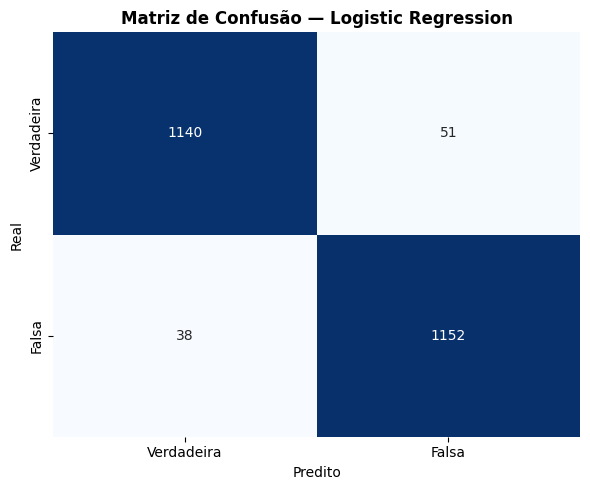

Relatório de Classificação — Logistic Regression:
              precision    recall  f1-score   support

           0       0.97      0.96      0.96      1191
           1       0.96      0.97      0.96      1190

    accuracy                           0.96      2381
   macro avg       0.96      0.96      0.96      2381
weighted avg       0.96      0.96      0.96      2381



In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Fazendo previsões com o modelo de Regressão Logística no conjunto de teste (ou gerando previsões de CV)
# Nota: Se preferir avaliar no X_test guardado na etapa anterior:
y_pred_lr = lr_model.predict(X_test)

# 2. Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Verdadeira', 'Falsa'],
            yticklabels=['Verdadeira', 'Falsa'])
plt.title('Matriz de Confusão — Logistic Regression', fontsize=12, fontweight='bold')
plt.xlabel('Predito', fontsize=10)
plt.ylabel('Real', fontsize=10)
plt.tight_layout()
plt.show()

# 3. Exibindo o relatório detalhado de métricas por classe
print("Relatório de Classificação — Logistic Regression:")
print(classification_report(y_test, y_pred_lr))

### 2. Linear SVM (Support Vector Machine Linear)
* **O que é:** Um classificador focado em encontrar o hiperplano de separação ideal com a maior margem possível entre as classes.
* **Por que usar:** Costuma ter excelente desempenho em tarefas de classificação de textos com vetores esparsos de TF-IDF, e apresentou o melhor resultado no Benchmark do notebook v1.

In [4]:
from sklearn.svm import LinearSVC

# Instancia o modelo
svm_model = LinearSVC(C=1.0, max_iter=2000, random_state=42, dual=False)

# Executa a Validação Cruzada
print("Executando Cross-Validation para Linear SVM...")
cv_svm = cross_validate(svm_model, X_train, y_train, cv=cv, scoring=['accuracy', 'precision', 'recall', 'f1'])

# Registra as métricas médias
resultados.append({
    'Modelo': 'Linear SVM',
    'Acurácia (CV)': cv_svm['test_accuracy'].mean(),
    'Precisão (CV)': cv_svm['test_precision'].mean(),
    'Recall (CV)': cv_svm['test_recall'].mean(),
    'F1-Score (CV)': cv_svm['test_f1'].mean()
})

# Treina no conjunto completo e salva no dicionário
svm_model.fit(X_train, y_train)
modelos_treinados['Linear SVM'] = svm_model

print(f"Linear SVM - F1-Score Médio (CV): {cv_svm['test_f1'].mean():.4f}")

Executando Cross-Validation para Linear SVM...
Linear SVM - F1-Score Médio (CV): 0.9642


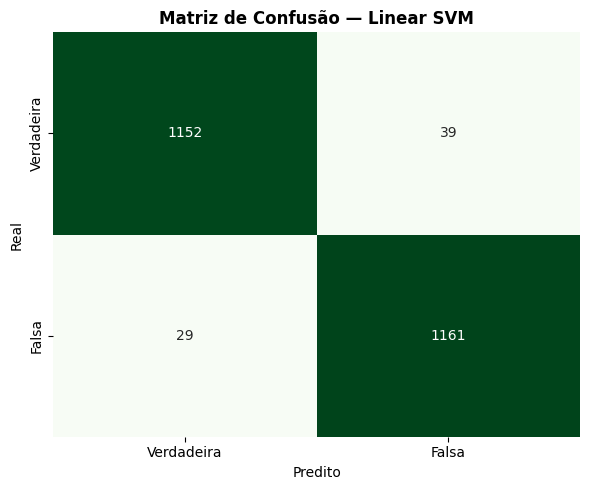

Relatório de Classificação — Linear SVM:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      1191
           1       0.97      0.98      0.97      1190

    accuracy                           0.97      2381
   macro avg       0.97      0.97      0.97      2381
weighted avg       0.97      0.97      0.97      2381



In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Fazendo previsões com o modelo Linear SVM no conjunto de teste
y_pred_svm = svm_model.predict(X_test)

# 2. Gerando a Matriz de Confusão
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Verdadeira', 'Falsa'],
            yticklabels=['Verdadeira', 'Falsa'])
plt.title('Matriz de Confusão — Linear SVM', fontsize=12, fontweight='bold')
plt.xlabel('Predito', fontsize=10)
plt.ylabel('Real', fontsize=10)
plt.tight_layout()
plt.show()

# 3. Exibindo o relatório detalhado de métricas por classe
print("Relatório de Classificação — Linear SVM:")
print(classification_report(y_test, y_pred_svm))

### 3. Random Forest
* **O que é:** Um modelo baseado em *ensemble* que combina centenas de árvores de decisão.
* **Por que usar:** Capaz de capturar interações não lineares complexas entre os termos do texto, embora possa ser mais custoso computacionalmente.

In [6]:
from sklearn.ensemble import RandomForestClassifier

# Instancia o modelo
rf_model = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42, n_jobs=-1)

# Executa a Validação Cruzada
print("Executando Cross-Validation para Random Forest...")
cv_rf = cross_validate(rf_model, X_train, y_train, cv=cv, scoring=['accuracy', 'precision', 'recall', 'f1'])

# Registra as métricas médias
resultados.append({
    'Modelo': 'Random Forest',
    'Acurácia (CV)': cv_rf['test_accuracy'].mean(),
    'Precisão (CV)': cv_rf['test_precision'].mean(),
    'Recall (CV)': cv_rf['test_recall'].mean(),
    'F1-Score (CV)': cv_rf['test_f1'].mean()
})

# Treina no conjunto completo e salva no dicionário
rf_model.fit(X_train, y_train)
modelos_treinados['Random Forest'] = rf_model

print(f"Random Forest - F1-Score Médio (CV): {cv_rf['test_f1'].mean():.4f}")

Executando Cross-Validation para Random Forest...
Random Forest - F1-Score Médio (CV): 0.9613


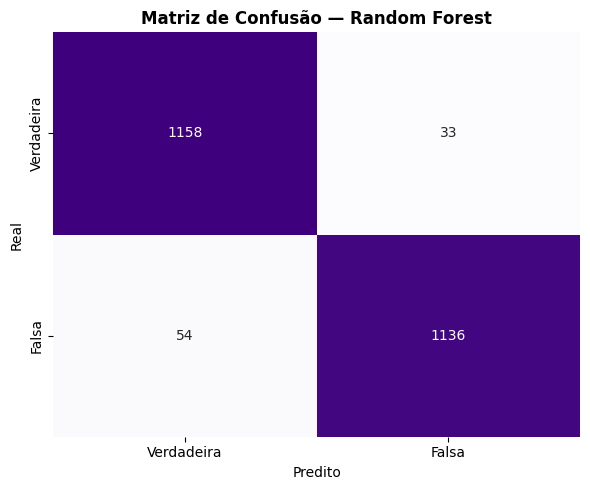

Relatório de Classificação — Random Forest:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1191
           1       0.97      0.95      0.96      1190

    accuracy                           0.96      2381
   macro avg       0.96      0.96      0.96      2381
weighted avg       0.96      0.96      0.96      2381



In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Fazendo previsões com o modelo Random Forest no conjunto de teste
y_pred_rf = rf_model.predict(X_test)

# 2. Gerando a Matriz de Confusão
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Verdadeira', 'Falsa'],
            yticklabels=['Verdadeira', 'Falsa'])
plt.title('Matriz de Confusão — Random Forest', fontsize=12, fontweight='bold')
plt.xlabel('Predito', fontsize=10)
plt.ylabel('Real', fontsize=10)
plt.tight_layout()
plt.show()

# 3. Exibindo o relatório detalhado de métricas por classe
print("Relatório de Classificação — Random Forest:")
print(classification_report(y_test, y_pred_rf))

### 4. Consolidação, Salvamento e Comparação Gráfica
Nesta última etapa, reunimos o desempenho de todos os modelos em uma tabela consolidada, salvamos os artefatos treinados em disco e geramos um gráfico comparativo para análise visual.


--- Resumo Comparativo das Métricas (Cross-Validation) ---


,Modelo,Acurácia (CV),Precisão (CV),Recall (CV),F1-Score (CV)
0,Logistic Regression,0.953997,0.949876,0.958621,0.954203
1,Linear SVM,0.964079,0.960037,0.968493,0.964237
2,Random Forest,0.961559,0.967888,0.954841,0.961302



Modelos base salvos com sucesso em '../models/modelos_base_treinados.pkl'


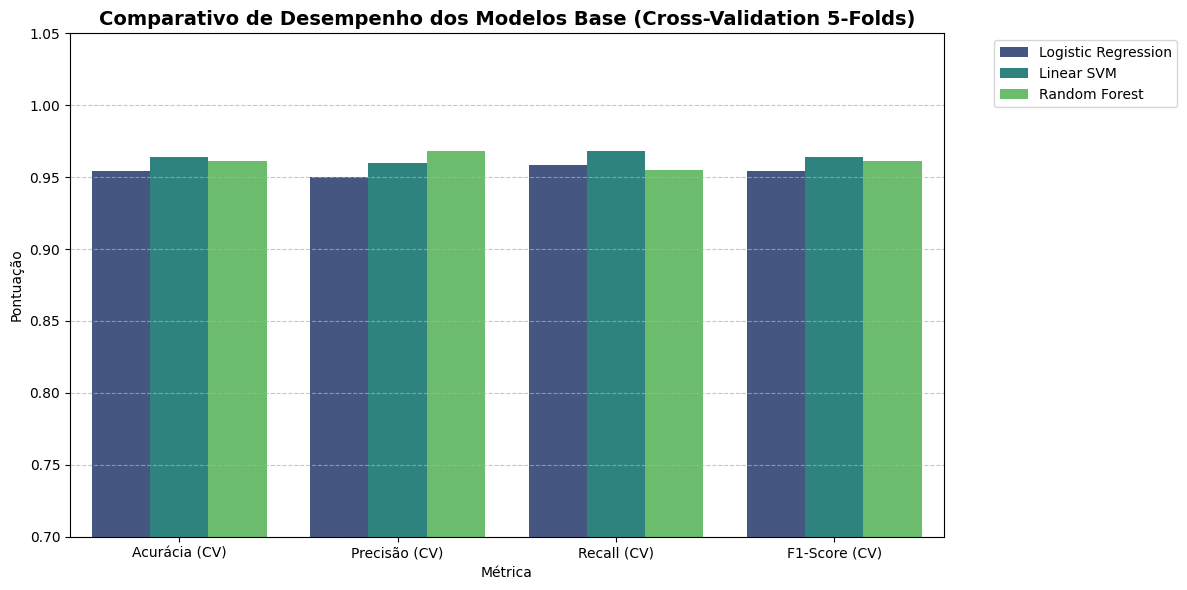

In [8]:
import os

# Converte os resultados acumulados em DataFrame
df_resultados = pd.DataFrame(resultados)
print("\n--- Resumo Comparativo das Métricas (Cross-Validation) ---")
display(df_resultados)

# Salvando os modelos base treinados
os.makedirs('../models', exist_ok=True)
joblib.dump(modelos_treinados, '../models/modelos_base_treinados.pkl')
print("\nModelos base salvos com sucesso em '../models/modelos_base_treinados.pkl'")

# ==========================================
# GRÁFICO COMPARATIVO
# ==========================================
df_melted = df_resultados.melt(id_vars='Modelo', var_name='Métrica', value_name='Pontuação')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Métrica', y='Pontuação', hue='Modelo', palette='viridis')
plt.title('Comparativo de Desempenho dos Modelos Base (Cross-Validation 5-Folds)', fontsize=14, fontweight='bold')
plt.ylim(0.7, 1.05) # Ajuste o limite inferior se necessário
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [9]:
import os
import joblib

# Cria a pasta data/processed na raiz do projeto se ela não existir
os.makedirs('../../data/processed', exist_ok=True)

# Salva as matrizes geradas no seu processo atual
joblib.dump(X_train, '../../data/processed/X_train_vec.pkl')
joblib.dump(X_test, '../../data/processed/X_test_vec.pkl')
joblib.dump(y_train, '../../data/processed/y_train.pkl')
joblib.dump(y_test, '../../data/processed/y_test.pkl')

print("✅ Matrizes de treino e teste salvas com sucesso!")

✅ Matrizes de treino e teste salvas com sucesso!
